# Explorar dataset de canciones

Este notebook carga el archivo de canciones guardado en la carpeta `data/` y muestra su contenido con pandas.

In [2]:
from pathlib import Path
import pandas as pd

data_dir = Path('..') / 'data'
files = [
    path for path in data_dir.iterdir()
    if path.suffix.lower() in {'.csv', '.xlsx', '.xls', '.json'}
]

if not files:
    raise FileNotFoundError(
        'No se encontró un archivo CSV, Excel o JSON en la carpeta data/.'
    )

dataset_path = files[0]
print(f'Archivo cargado: {dataset_path.name}')

Archivo cargado: top 100 streamed_songs.csv


In [3]:
if dataset_path.suffix.lower() == '.csv':
    df = pd.read_csv(dataset_path)
elif dataset_path.suffix.lower() in {'.xlsx', '.xls'}:
    df = pd.read_excel(dataset_path)
else:
    df = pd.read_json(dataset_path)

df.head()

,id,name,duration,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,danceability
0,4ZtFanR9U6ndgddUvNcjcG,Good 4 U Olivia Rodrigo,2.97,0.664,9,-5.044,1,0.1540,0.33500,0.000,0.0849,0.688,166.928,0.563
1,5fxyZf6m2xHeSrOzUfcJrq,Stay The Kid LAROI & Justin Bieber,2.30,0.506,8,-11.275,1,0.0589,0.37900,0.868,0.1100,0.454,170.054,0.564
2,5nujrmhLynf4yMoMtj8AQF,Levitating Dua Lipa feat. DaBaby,3.38,0.825,6,-3.787,0,0.0601,0.00883,0.000,0.0674,0.915,102.977,0.702
3,4iJyoBOLtHqaGxP12qzhQI,Peaches Justin Bieber feat. Daniel Caesar & Gi...,3.30,0.696,0,-6.181,1,0.1190,0.32100,0.000,0.4200,0.464,90.030,0.677
4,1SC5rEoYDGUK4NfG82494W,Montero (Call Me By Your Name) Lil Nas X,2.30,0.503,8,-6.725,0,0.2200,0.29300,0.000,0.4050,0.710,178.781,0.593


In [ ]:
print(f'Filas: {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')
df.info()

Filas: 100
Columnas: 14
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                100 non-null    str    
 1   name              100 non-null    str    
 2   duration          100 non-null    float64
 3   energy            100 non-null    float64
 4   key               100 non-null    int64  
 5   loudness          100 non-null    float64
 6   mode              100 non-null    int64  
 7   speechiness       100 non-null    float64
 8   acousticness      100 non-null    float64
 9   instrumentalness  100 non-null    float64
 10  liveness          100 non-null    float64
 11  valence           100 non-null    float64
 12  tempo             100 non-null    float64
 13  danceability      100 non-null    float64
dtypes: float64(10), int64(2), str(2)
memory usage: 11.1 KB


## Auditoría del dataset

Este análisis responde:

1. ¿Qué tamaño tiene y qué contiene?
2. ¿Cuál es el tipo real de cada columna?
3. ¿Hay valores faltantes?
4. ¿Hay filas duplicadas?
5. ¿Cuál es el rango de cada variable numérica y parece razonable?

In [ ]:
# 1. Tamaño y contenido
print('1. TAMAÑO Y CONTENIDO')
print(f'Filas: {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')
print(f'Tamaño en memoria: {df.memory_usage(deep=True).sum() / 1024:.2f} KB')
print('\nColumnas:')
print(', '.join(df.columns))
print('\nMuestra:')
display(df.head())

# 2. Tipos reales
print('\n2. TIPOS DE DATOS')
tipos = pd.DataFrame({
    'columna': df.columns,
    'tipo_pandas': [df[columna].dtype for columna in df.columns],
    'tipo_python_muestra': [type(df[columna].dropna().iloc[0]).__name__ if df[columna].notna().any() else 'sin valores' for columna in df.columns],
    'valores_unicos': [df[columna].nunique(dropna=True) for columna in df.columns],
})
display(tipos)

# 3. Valores faltantes
print('\n3. VALORES FALTANTES')
faltantes = pd.DataFrame({
    'faltantes': df.isna().sum(),
    'porcentaje': (df.isna().mean() * 100).round(2),
})
display(faltantes)
print('¿Hay algún valor faltante?', df.isna().any().any())

# 4. Duplicados
print('\n4. DUPLICADOS')
print(f'Filas duplicadas completas: {df.duplicated().sum()}')
print(f'IDs duplicados: {df["id"].duplicated().sum()}')

# 5. Rangos y comprobaciones de plausibilidad
print('\n5. RANGOS NUMÉRICOS Y PLAUSIBILIDAD')
columnas_numericas = df.select_dtypes(include='number').columns
rangos = df[columnas_numericas].agg(['min', 'max', 'mean']).T.round(3)
display(rangos)

reglas = {
    'duration': (0, 15),
    'energy': (0, 1),
    'key': (0, 11),
    'loudness': (-60, 5),
    'mode': (0, 1),
    'speechiness': (0, 1),
    'acousticness': (0, 1),
    'instrumentalness': (0, 1),
    'liveness': (0, 1),
    'valence': (0, 1),
    'tempo': (0, 300),
    'danceability': (0, 1),
}
chequeos = []
for columna, (minimo, maximo) in reglas.items():
    if columna in df.columns:
        fuera_de_rango = (~df[columna].between(minimo, maximo)).sum()
        chequeos.append({
            'columna': columna,
            'rango_esperado': f'{minimo} a {maximo}',
            'fuera_de_rango': fuera_de_rango,
            'resultado': 'OK' if fuera_de_rango == 0 else 'REVISAR',
        })
display(pd.DataFrame(chequeos))

print('\nConclusión:')
print('Los rangos se consideran plausibles cuando no hay valores fuera de los límites esperados.')

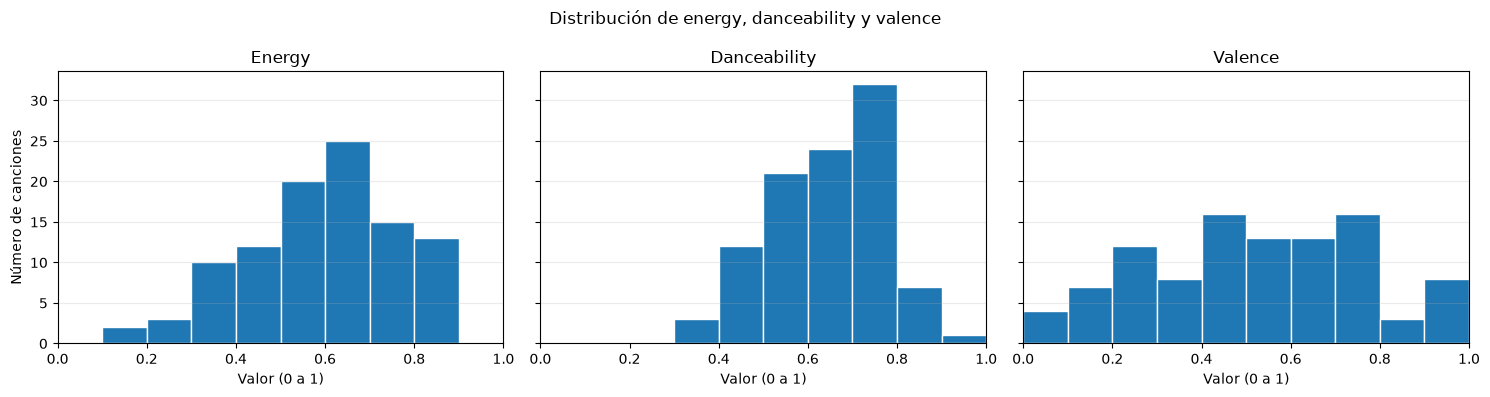

In [4]:
import matplotlib.pyplot as plt

variables = ['energy', 'danceability', 'valence']
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, variable in zip(axes, variables):
    ax.hist(df[variable].dropna(), bins=10, range=(0, 1), edgecolor='white')
    ax.set_title(variable.capitalize())
    ax.set_xlabel('Valor (0 a 1)')
    ax.set_xlim(0, 1)
    ax.grid(axis='y', alpha=0.25)

axes[0].set_ylabel('Número de canciones')
fig.suptitle('Distribución de energy, danceability y valence')
fig.tight_layout()
plt.show()

### Cómo explicar los histogramas

- **Energy:** la mayoría de las canciones se concentra aproximadamente entre 0.5 y 0.8. La mediana es 0.609 y la mitad central de los valores está entre 0.478 y 0.708. En esta selección predominan canciones de energía moderada a alta, aunque también hay algunas con energía baja.
- **Danceability:** los valores se agrupan sobre todo entre 0.5 y 0.8. La mediana es 0.664 y la mitad central está entre 0.567 y 0.734. Esto sugiere que muchas canciones tienen una bailabilidad de moderada a alta, pero no que todas sean altamente bailables.
- **Valence:** presenta una distribución más extendida: la mitad central va de 0.329 a 0.712 y el rango observado va de 0.059 a 0.967. La lista reúne canciones con estados de ánimo musicales variados; el promedio, por sí solo, escondería esa diversidad.

**Idea para presentar:** estos histogramas describen cómo se distribuyen las características dentro de estas 100 canciones. No explican por sí solos por qué fueron populares ni representan necesariamente toda la música.

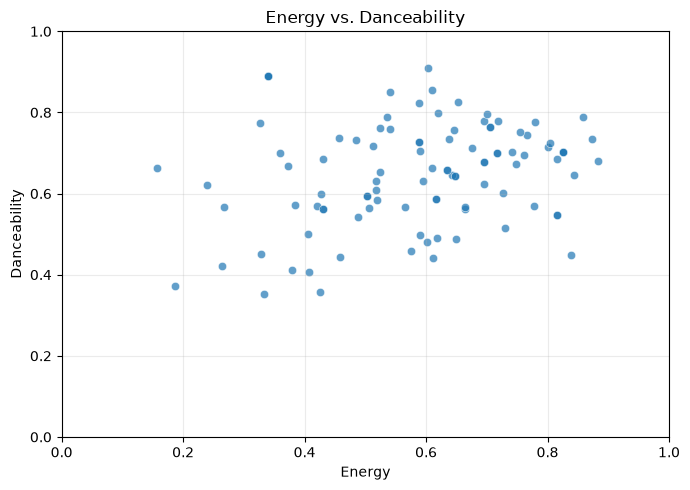

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['energy'], df['danceability'], alpha=0.7, edgecolors='white', linewidths=0.5)
ax.set_title('Energy vs. Danceability')
ax.set_xlabel('Energy')
ax.set_ylabel('Danceability')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

### Cómo explicar energy vs. danceability

Cada punto representa una canción. Se aprecia una ligera tendencia ascendente: las canciones con mayor energía tienden, en promedio, a ser algo más bailables. Sin embargo, los puntos están bastante dispersos y la correlación es débil (r = 0.253), así que la energía no permite predecir por sí sola la bailabilidad.

**Idea para presentar:** energía y bailabilidad están relacionadas solo parcialmente; hay canciones enérgicas que no son especialmente bailables y canciones bailables con energía moderada. Es una asociación, no evidencia de causalidad.

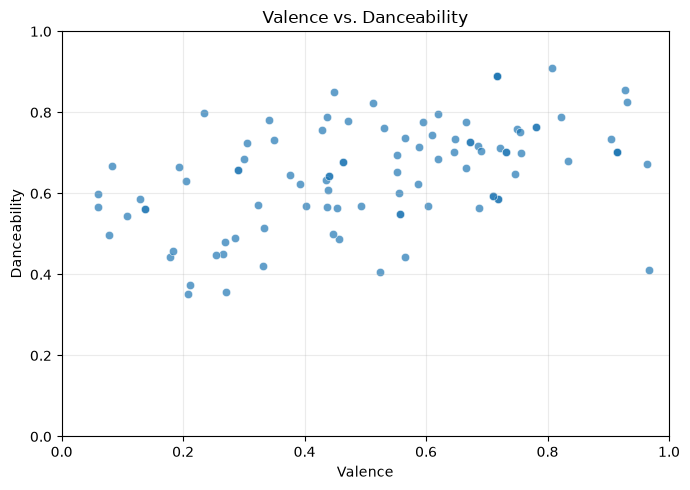

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['valence'], df['danceability'], alpha=0.7, edgecolors='white', linewidths=0.5)
ax.set_title('Valence vs. Danceability')
ax.set_xlabel('Valence')
ax.set_ylabel('Danceability')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

### Cómo explicar valence vs. danceability

La nube muestra una tendencia ascendente más clara que en el gráfico anterior: las canciones con mayor valence suelen tener también mayor danceability. La correlación es positiva moderada (r = 0.479), pero hay bastante variación alrededor de esa tendencia y algunas excepciones.

**Idea para presentar:** el carácter más alegre de una canción suele coincidir con mayor bailabilidad en esta selección, aunque no siempre. La relación no demuestra que una característica cause la otra, ni que explique la popularidad.

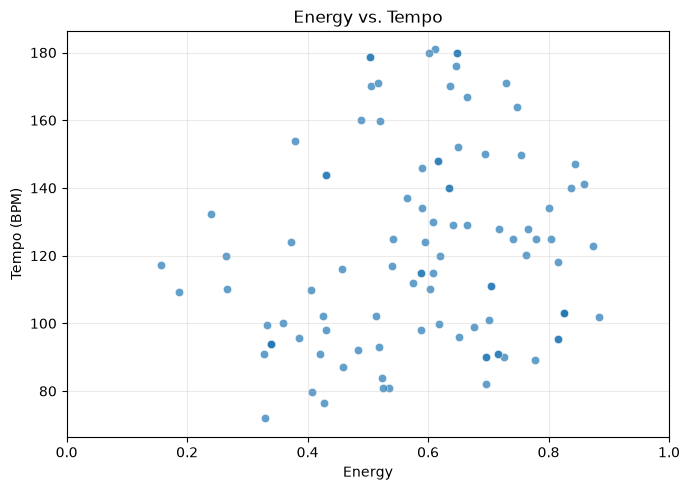

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['energy'], df['tempo'], alpha=0.7, edgecolors='white', linewidths=0.5)
ax.set_title('Energy vs. Tempo')
ax.set_xlabel('Energy')
ax.set_ylabel('Tempo (BPM)')
ax.set_xlim(0, 1)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

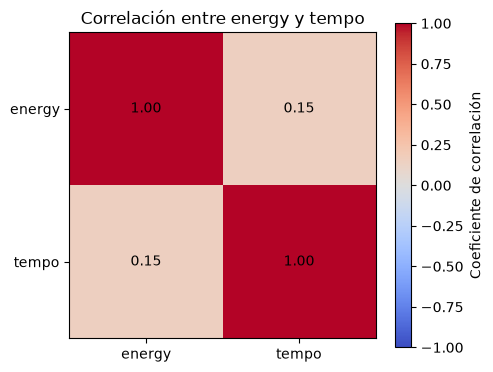

In [8]:
correlacion = df[['energy', 'tempo']].corr()
fig, ax = plt.subplots(figsize=(5, 4))
imagen = ax.imshow(correlacion, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(correlacion.columns)), labels=correlacion.columns)
ax.set_yticks(range(len(correlacion.index)), labels=correlacion.index)
ax.set_title('Correlación entre energy y tempo')

for fila in range(len(correlacion.index)):
    for columna in range(len(correlacion.columns)):
        ax.text(columna, fila, f'{correlacion.iloc[fila, columna]:.2f}',
                ha='center', va='center', color='black')

fig.colorbar(imagen, ax=ax, label='Coeficiente de correlación')
fig.tight_layout()
plt.show()